## Data Collection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests 
from bs4 import BeautifulSoup
import json
from pprint import pprint
import matplotlib.image as mpimg
import matplotlib.patches as patches
from PIL import Image
from io import BytesIO
import highlight_text
import matplotlib as mpl
from matplotlib.gridspec import GridSpec
from mplsoccer import Pitch, VerticalPitch
import matplotlib.image as mpimg
import matplotlib.patches as patches
from PIL import Image
from io import BytesIO
from mplsoccer import PyPizza, add_image, FontManager
from matplotlib.patches import Rectangle
import matplotlib.font_manager as font_manager
import matplotlib.image as mpimg
import matplotlib.patches as patches
from PIL import Image
from io import BytesIO
from mplsoccer import PyPizza, add_image, FontManager
#import soccerdata as sd
import re
from unidecode import unidecode
from scipy.spatial import ConvexHull
from matplotlib.colors import LinearSegmentedColormap
from highlight_text import ax_text, fig_text
import matplotlib.patheffects as path_effects
from scipy.ndimage import gaussian_filter
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patheffects as path_effects


from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By
#import main
#import visuals
import seaborn as sns
import requests
#import utils
import os
%load_ext autoreload
%autoreload 2

pd.set_option("display.max_rows", None, "display.max_columns", None)
background = "#010b14"
#background = "white"
text_color = 'black'
primary = '#C8102E'
secondary = 'lightblue'
mpl.rcParams['xtick.color'] = text_color
mpl.rcParams['ytick.color'] = text_color

In [2]:
import matplotlib.font_manager as fm
from mplsoccer import FontManager
base_path = '/Users/ishdeepchadha/Documents/PlayBack90/Streamlit/Data'
plot_path = '/Users/ishdeepchadha/Documents/Score/Plots'
font_path = '/Users/ishdeepchadha/Documents/Score/Football'
# Set the path to the locally downloaded font file
font_path = f'{font_path}/Sora_Font/Sora-Regular.ttf'

# Add the font to matplotlib
font_prop = fm.FontProperties(fname=font_path)

# You can now use this font in your plots
fm_sora = FontManager()
#fm_sora.prop = font_prop

print("Font loaded and registered successfully!")

Font loaded and registered successfully!


In [3]:
import sqlite3
import pandas as pd

# Replace with your path
conn = sqlite3.connect(f'{base_path}/playback90.db')
query = "SELECT * FROM event_data where league = 'premier-league' and season = '2025/2026';"
df = pd.read_sql_query(query, conn)

In [4]:
import pandas as pd

def tag_sequences_and_possessions_all_matches(
        df,
        match_col="matchId",
        event_col="type",
        team_col="teamName",
        outcome_col="outcomeType",
        success_values=("Successful", 1),
        time_sort_cols=("minute", "second", "index")
    ):
    """
    Adds `sequence_id` and `possession_id` *per match*.

    Parameters
    ----------
    df : pd.DataFrame
        Event feed containing one or more matches.
    match_col : str
        Column that identifies each match.
    All other parameters are identical to the single‑match function.

    Returns
    -------
    pd.DataFrame
        Same rows plus `sequence_id` and `possession_id`.
    """

    # ---------- 1. Define event buckets ----------
    CONTROLLED_EVENTS = {
        "Pass", "BallRecovery", "BallTouch", "KeeperPickup", "TakeOn",
        "Goal", "SavedShot", "Claim", "Carry", "ShotOnPost"
    }
    DEFENSIVE_EVENTS = {
        "Tackle", "Dispossessed", "Interception", "Clearance", "BlockedPass",
        "Challenge", "Aerial", "KeeperSweeper", "Punch"
    }
    STOPPAGE_EVENTS = {
        "Foul", "OffsidePass", "OffsideGiven", "OffsideProvoked",
        "Card", "Error", "CornerAwarded", "MissedShots", "ChanceMissed",
        "End", "FormationChange", "SubstitutionOn", "SubstitutionOff",
        "FormationSet", "Start"
    }

    # ---------- 2. Helper to tag ONE match ----------
    def _tag_one_match(sub):
        # Sort chronologically inside this match
        sub = sub.sort_values(list(time_sort_cols)).reset_index(drop=True)

        poss_id = -1
        seq_id  = -1
        possessing_team = None
        open_sequence   = False

        poss_ids, seq_ids = [], []

        for _, row in sub.iterrows():
            ev   = row[event_col]
            team = row[team_col]
            ok   = row[outcome_col] in success_values

            grants_control = (ev in CONTROLLED_EVENTS) and ok

            # Turnover?
            if possessing_team is not None and grants_control and team != possessing_team:
                poss_id += 1
                seq_id  += 1
                possessing_team = team
                open_sequence   = True

            # Sequence‑ending tests
            terminate = False
            if open_sequence:
                if ev in STOPPAGE_EVENTS or ev == "Goal":
                    terminate = True
                elif team != possessing_team and ev in DEFENSIVE_EVENTS:
                    terminate = True
                elif (ev in CONTROLLED_EVENTS) and not ok:
                    terminate = True

            if terminate:
                open_sequence = False
                if team != possessing_team and ev in DEFENSIVE_EVENTS:
                    possessing_team = None

            # Sequence‑start tests
            if not open_sequence and grants_control:
                if team != possessing_team:
                    poss_id += 1
                    possessing_team = team
                seq_id      += 1
                open_sequence = True

            seq_ids.append(seq_id if open_sequence else pd.NA)
            poss_ids.append(poss_id if possessing_team is not None else pd.NA)

        sub["sequence_id"]   = seq_ids
        sub["possession_id"] = poss_ids
        return sub

    # ---------- 3. Run per‑match and concatenate ----------
    out = (
        df.groupby(match_col, group_keys=False, sort=False)
          .apply(_tag_one_match)
          .reset_index(drop=True)
    )
    return out


poss_df = tag_sequences_and_possessions_all_matches(df)

/var/folders/1p/x285c99d20ggyt7j19j59bdm0000gn/T/ipykernel_5438/633443468.py:104: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_tag_one_match)


## Model

In [5]:
print(list(poss_df.columns))

['index', 'eventId', 'minute', 'second', 'teamId', 'x', 'y', 'expandedMinute', 'period', 'type', 'outcomeType', 'qualifiers', 'satisfiedEventsTypes', 'isTouch', 'playerId', 'endX', 'endY', 'blockedX', 'blockedY', 'goalMouthZ', 'goalMouthY', 'isShot', 'relatedEventId', 'relatedPlayerId', 'isGoal', 'cardType', 'isOwnGoal', 'cumulative_mins', 'playerName', 'h_a', 'matchId', 'startDate', 'startTime', 'score', 'ftScore', 'htScore', 'etScore', 'venueName', 'maxMinute', 'shotBodyType', 'situation', 'shotSixYardBox', 'shotPenaltyArea', 'shotOboxTotal', 'shotOpenPlay', 'shotCounter', 'shotSetPiece', 'shotDirectCorner', 'shotOffTarget', 'shotOnPost', 'shotOnTarget', 'shotsTotal', 'shotBlocked', 'shotRightFoot', 'shotLeftFoot', 'shotHead', 'shotObp', 'goalSixYardBox', 'goalPenaltyArea', 'goalObox', 'goalOpenPlay', 'goalCounter', 'goalSetPiece', 'penaltyScored', 'goalOwn', 'goalNormal', 'goalRightFoot', 'goalLeftFoot', 'goalHead', 'goalObp', 'shortPassInaccurate', 'shortPassAccurate', 'passCorner'

In [ ]:
poss_df['pass_distance'] = np.sqrt((poss_df['endX'] - poss_df['x'])**2 + (poss_df['endY'] - poss_df['y'])**2)
poss_df['carry_distance_before_pass'] = 0.0
for i in poss_df[poss_df['type'] == 'Pass'].index:
    current_player = poss_df.at[i, 'playerId']
    previous = poss_df.iloc[:i]
    previous = previous[previous['playerId'] == current_player]
    previous = previous[previous['type'] == 'Carry']
    if not previous.empty:
        last_carry = previous.iloc[-1]
        dist = np.sqrt((last_carry['endX'] - last_carry['x'])**2 + (last_carry['endY'] - last_carry['y'])**2)
        poss_df.at[i, 'carry_distance_before_pass'] = dist

poss_df['vertical_progression_speed'] = 0.0
for i in range(len(poss_df)):
    current_team = poss_df.at[i, 'teamId']
    team_events = poss_df.iloc[max(0, i-3):i]
    team_events = team_events[team_events['teamId'] == current_team]
    if len(team_events) < 2:
        continue
    dy = poss_df.at[i, 'y'] - team_events.iloc[0]['y']
    dt = (poss_df.at[i, 'minute'] * 60 + poss_df.at[i, 'second']) - (team_events.iloc[0]['minute'] * 60 + team_events.iloc[0]['second'])
    if dt != 0:
        poss_df.at[i, 'vertical_progression_speed'] = dy / dt

In [12]:
poss_df['previous_action_team_same'] = (poss_df['teamId'] == poss_df['teamId'].shift(1)).astype(int)
poss_df['previous_pass_distance'] = 0.0
poss_df['previous_pass_angle'] = 0.0

for i in range(1, len(poss_df)):
    if poss_df.at[i-1, 'type'] == 'Pass':
        dx = poss_df.at[i-1, 'endX'] - poss_df.at[i-1, 'x']
        dy = poss_df.at[i-1, 'endY'] - poss_df.at[i-1, 'y']
        poss_df.at[i, 'previous_pass_distance'] = np.sqrt(dx**2 + dy**2)
        poss_df.at[i, 'previous_pass_angle'] = np.arctan2(dy, dx)

poss_df['pass_count_in_possession'] = poss_df.groupby('possession_id').cumcount() + 1
poss_df['pass_count_log'] = np.log1p(poss_df['pass_count_in_possession'])
body_parts = ['passRightFoot', 'passLeftFoot', 'passHead']
pass_types = [
    'passChipped', 'passCrossAccurate', 'passCrossInaccurate',
    'passLongBallAccurate', 'passLongBallInaccurate',
    'passThroughBallAccurate', 'passThroughBallInaccurate', 'passThroughBallInacurate', 'passBack' , 'passForward', 'passLeft', 'passRight'
]
set_piece_types = [
    'passFreekickAccurate', 'passFreekickInaccurate',
    'passCorner', 'passCornerAccurate', 'passCornerInaccurate'
]

features = [
    'x', 'y', 'pass_distance', 'pass_or_carry_angle',
    'carry_distance_before_pass', 'vertical_progression_speed',
    'previous_action_team_same', 'previous_pass_distance', 'previous_pass_angle',
    'pass_count_log'
] + body_parts + pass_types + set_piece_types


In [13]:
nan_check = poss_df[features].isna().sum()
print(nan_check[nan_check > 0])


pass_distance                 289857
pass_or_carry_angle           289857
vertical_progression_speed      1386
pass_count_log                 50692
dtype: int64


In [14]:
# Impute missing numerical values with 0 (safe default)
fill_0_features = ['pass_distance', 'pass_or_carry_angle', 'vertical_progression_speed', 'pass_count_log']
poss_df[fill_0_features] = poss_df[fill_0_features].fillna(0)

# Optional: if any boolean flags or pass types have NaNs (can check similarly)
bool_cols = body_parts + pass_types + set_piece_types
poss_df[bool_cols] = poss_df[bool_cols].fillna(0)


In [13]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

# Define target and features
target = 'passAccurate'
X = poss_df[features]
y = poss_df[target]

# Train/validation split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# XGBoost classifier
model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

# Train the model
model.fit(X_train, y_train)

# Predictions
y_pred_proba = model.predict_proba(X_val)[:, 1]
y_pred = model.predict(X_val)

# Evaluation
auc = roc_auc_score(y_val, y_pred_proba)
acc = accuracy_score(y_val, y_pred)

print(f"AUC: {auc:.4f}")
print(f"Accuracy: {acc:.4f}")


AUC: 0.9863
Accuracy: 0.9470


In [51]:
y_pred_proba

array([5.9065380e-04, 1.5415181e-01, 9.6407217e-01, ..., 9.4301045e-01,
       7.9932988e-01, 7.7553695e-01], shape=(528400,), dtype=float32)

In [14]:
# Mask to select only Pass events
pass_mask = poss_df['type'] == 'Pass'

# Predict only on those rows
poss_df.loc[pass_mask, 'xPass'] = model.predict_proba(poss_df.loc[pass_mask, features])[:, 1]


In [15]:
import joblib

# Save model to disk
joblib.dump(model, 'xpass_model.joblib')
print("Model saved as 'xpass_model.joblib'")


Model saved as 'xpass_model.joblib'


In [16]:
poss_df[poss_df['type'] == 'Pass']['xPass'].isna().sum()

np.int64(0)

In [15]:
# Features used in model
features = [
    'x', 'y', 'pass_distance', 'pass_or_carry_angle',
    'carry_distance_before_pass', 'vertical_progression_speed',
    'previous_action_team_same', 'previous_pass_distance', 'previous_pass_angle',
    'pass_count_log'
] + body_parts + pass_types + set_piece_types

# Check missing values in Pass rows
missing_counts = poss_df[poss_df['type'] == 'Pass'][features].isna().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)
print(missing_counts)


Series([], dtype: int64)


In [109]:
poss_df[poss_df['type'] == 'Pass'][['playerName','passAccurate','xPass']].head(20)

,playerName,passAccurate,xPass
2,Kevin Stoger,1.0,0.798438
7,Ko Itakura,0.0,0.001266
8,Jonathan Tah,0.0,0.080004
9,Julian Weigl,0.0,0.116134
11,Edmond Tapsoba,0.0,0.000921
12,Ko Itakura,1.0,0.132060
13,Julian Weigl,1.0,0.943234
14,Nico Elvedi,1.0,0.982778
15,Jonas Omlin,1.0,0.866074
16,Nico Elvedi,1.0,0.898002


## Analysis

In [5]:
import joblib

# Replace with your correct path and filename
xpass_model = joblib.load('xpass_model.joblib')


In [17]:
# Mask to select only Pass events
pass_mask = poss_df['type'] == 'Pass'

# Predict only on those rows
poss_df.loc[pass_mask, 'xPass'] = xpass_model.predict_proba(poss_df.loc[pass_mask, features])[:, 1]


In [18]:
xPdf = poss_df.copy()

In [19]:
xPdf['league'].unique()

array(['premier-league'], dtype=object)

In [20]:
pl = xPdf[xPdf['league'] == 'premier-league']

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Clean playerName column of true NaNs and string 'nan', 'none', ''
pl = pl[pl['playerName'].notna()].copy()
pl = pl[~pl['playerName'].astype(str).str.lower().isin(['nan', 'none', ''])].copy()

# Group by player to calculate total xPass and passes attempted
player_stats = pl.groupby('playerName').agg(
    passes_attempted=('passAccurate', 'count'),
    xPass_total=('xPass', 'sum')
).reset_index()

# Filter players with at least 1500 passes
player_stats = player_stats[player_stats['passes_attempted'] >= 1500].copy()

# Compute mean xPass
player_stats['mean_xPass'] = player_stats['xPass_total'] / player_stats['passes_attempted']

# Get top 5 and bottom 5 by mean xPass
top5_xPass = player_stats.nlargest(5, 'mean_xPass')
bottom5_xPass = player_stats.nsmallest(5, 'mean_xPass')

# Combine and sort for plotting
combined_xPass = pd.concat([top5_xPass, bottom5_xPass]).sort_values('mean_xPass')

# Assign color based on whether the player is in top or bottom 5
combined_xPass['color'] = combined_xPass['playerName'].apply(
    lambda x: 'green' if x in top5_xPass['playerName'].values else 'red'
)


In [23]:
top5_xPass

,playerName,passes_attempted,xPass_total,mean_xPass
124,Ezri Konsa,3670,2606.611328,0.710248
368,Ruben Dias,3826,2661.195801,0.695556
212,John Stones,3172,2202.807129,0.694454
219,Josh Acheampong,1819,1243.617676,0.683682
344,Pau Torres,2034,1382.432495,0.679662


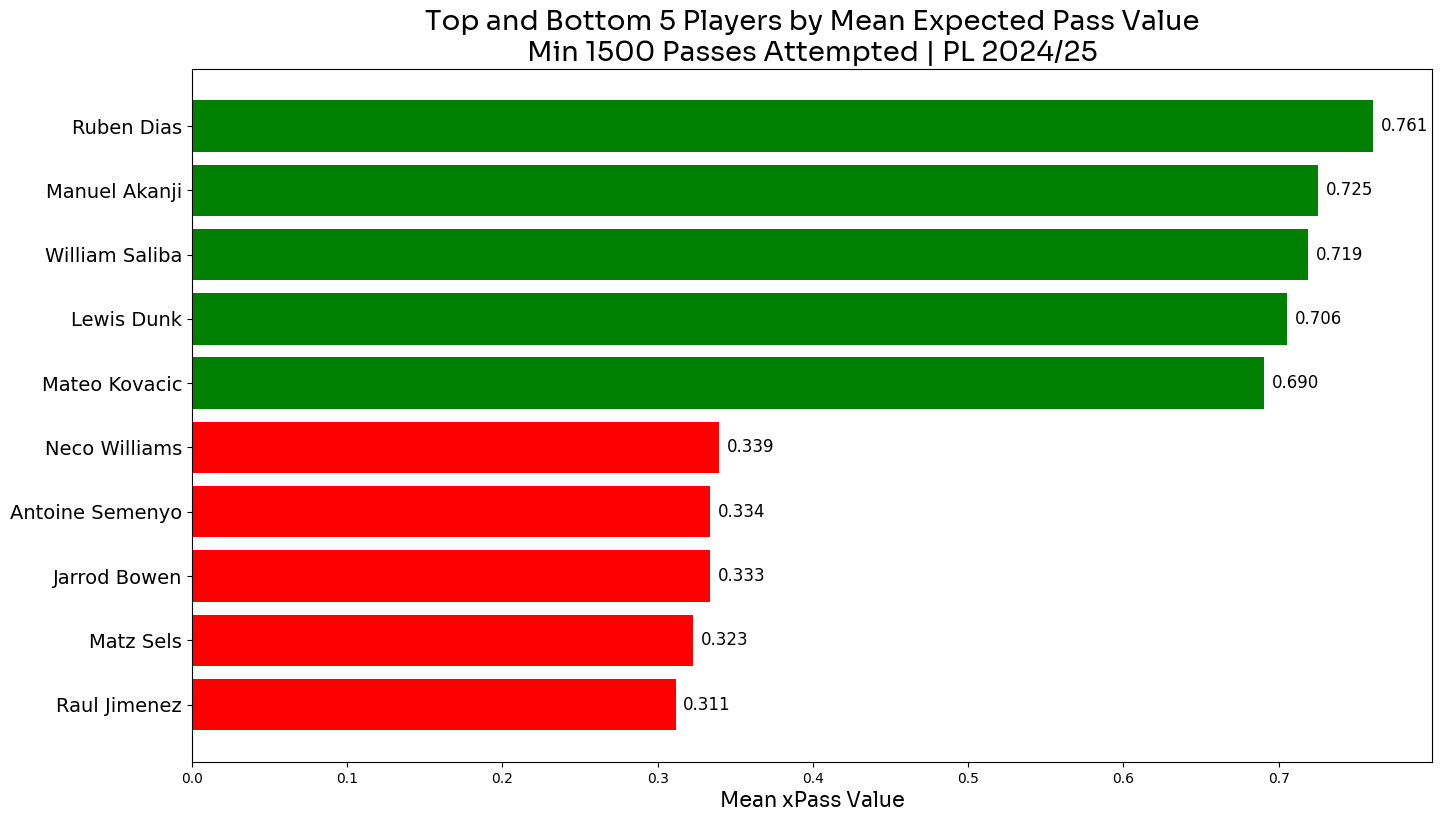

In [21]:
# Plot horizontal bar graph
plt.figure(figsize=(16, 9))
bars = plt.barh(combined_xPass['playerName'], combined_xPass['mean_xPass'], color=combined_xPass['color'])
plt.xlabel('Mean xPass Value',fontproperties=font_prop, fontsize=15)
plt.yticks(fontsize=14)  # or any size you prefer

plt.title(f'Top and Bottom 5 Players by Mean Expected Pass Value\nMin 1500 Passes Attempted | PL 2024/25',fontproperties=font_prop, fontsize=20)
plt.grid(False)

# Annotate bars with mean xPass values
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.005, bar.get_y() + bar.get_height() / 2, f"{width:.3f}", va='center', fontsize=12)

plt.savefig(f'{plot_path}/xPass/Mean_xPass.png',dpi=500,bbox_inches = 'tight',facecolor='white')


In [129]:
player_stats[player_stats['playerName'] == 'Omar El Hilali']

,playerName,passes_attempted,passes_completed,xPass_total,paxp_per_100
430,Omar El Hilali,1574,987.0,980.962219,0.383595


In [128]:
import matplotlib.pyplot as plt
import pandas as pd

# Filter valid player names
#xPdf = xPdf[~xPdf['playerName'].isna() & (xPdf['playerName'] != '')].copy()
result = xPdf.copy()
#result = result[(result['league'] == 'premier-league') & (result['x'] > 70) & (result['endX'] < 105)]
result = result[(result['league'] == 'laliga')]
result = result[~result['playerName'].isna() & (result['playerName'] != '')].copy()

# Group by player to get total values
player_stats = result.groupby('playerName').agg(
    passes_attempted=('xPass', 'count'),
    passes_completed=('passAccurate', 'sum'),
    xPass_total=('xPass', 'sum')
).reset_index()

# Filter players with at least 1500 passes
player_stats = player_stats[player_stats['passes_attempted'] >= 500].copy()

# Calculate Passes Above Expected per 100 passes
player_stats['paxp_per_100'] = ((player_stats['passes_completed'] - player_stats['xPass_total']) 
                                / player_stats['passes_attempted']) * 100

# Get top and bottom 5 players
top5_per100 = player_stats.nlargest(5, 'paxp_per_100')
bottom5_per100 = player_stats.nsmallest(5, 'paxp_per_100')

# Combine and sort for plotting
combined_per100 = pd.concat([bottom5_per100, top5_per100])
combined_per100 = combined_per100.sort_values('paxp_per_100')

In [120]:
combined_per100

,playerName,passes_attempted,passes_completed,xPass_total,paxp_per_100
343,Mohamed Salah,767,503.0,534.388367,-4.092356
59,Bryan Mbeumo,768,445.0,468.439850,-3.052064
261,Kevin De Bruyne,725,465.0,485.337067,-2.805113
275,Leandro Trossard,563,374.0,386.578278,-2.234152
27,Anthony Gordon,535,312.0,322.858612,-2.029647
387,Pedro Neto,617,406.0,391.312958,2.380396
63,Callum Hudson-Odoi,516,395.0,381.278351,2.659234
48,Bernardo Silva,745,587.0,566.157959,2.797589
108,Declan Rice,628,425.0,401.766968,3.699527
316,Mateo Kovacic,539,499.0,477.970978,3.901488


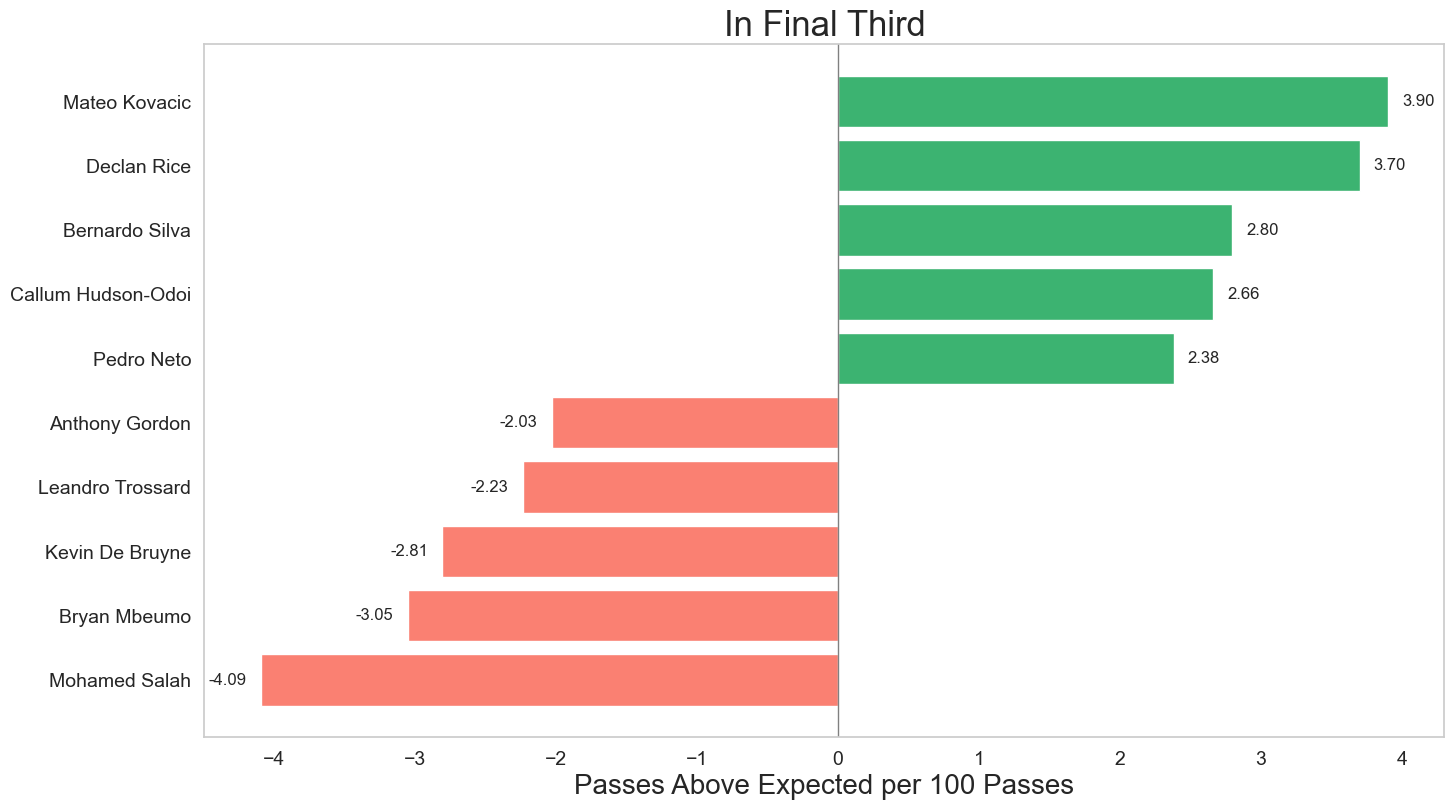

In [121]:
# Plot
plt.figure(figsize=(16, 9))
colors = ['salmon' if val < 0 else 'mediumseagreen' for val in combined_per100['paxp_per_100']]
bars = plt.barh(combined_per100['playerName'], combined_per100['paxp_per_100'], color=colors)

# Annotate bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + (0.1 if width > 0 else -0.1), 
             bar.get_y() + bar.get_height()/2, 
             f"{width:.2f}", 
             va='center',
             ha='left' if width > 0 else 'right',fontsize=12)

# Style the plot
plt.axvline(0, color='gray', linewidth=1)
plt.title(f'In Final Third', fontsize=25)
plt.xlabel('Passes Above Expected per 100 Passes', fontsize=20)
plt.yticks(fontsize=14)
plt.xticks(fontsize=14)
plt.grid(False)

plt.savefig(f'{plot_path}/xPass/PAxP_Attack.png',dpi=500,bbox_inches = 'tight',facecolor='white')


In [24]:
pos_xPdf = xPdf.copy()

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure timestamp exists
pos_xPdf['timestamp'] = pos_xPdf['minute'] * 60 + pos_xPdf['second']

# Sort for proper time logic
pos_xPdf = pos_xPdf.sort_values(by=['matchId', 'possession_id', 'minute', 'second'])

# Step 1: Possession duration per team per match
poss_time = (
    pos_xPdf.groupby(['matchId', 'possession_id', 'teamName'])['timestamp']
    .agg(['min', 'max'])
    .reset_index()
)
poss_time['duration'] = poss_time['max'] - poss_time['min']

team_poss_time = (
    poss_time.groupby(['matchId', 'teamName'])['duration']
    .sum()
    .reset_index(name='team_possession_time')
)

match_total_time = (
    team_poss_time.groupby('matchId')['team_possession_time']
    .sum()
    .reset_index(name='total_match_time')
)

team_poss_time = team_poss_time.merge(match_total_time, on='matchId')
team_poss_time['possession_pct'] = (team_poss_time['team_possession_time'] / team_poss_time['total_match_time']) * 100

# Average possession % per team
avg_team_possession = team_poss_time.groupby('teamName')['possession_pct'].mean().reset_index(name='avg_possession_pct')


# Step 2: Team pass statistics
# Filter valid passes
pass_df = pos_xPdf[(pos_xPdf['type'] == 'Pass')].copy()

team_pass_stats = pass_df.groupby('teamName').agg(
    passes_attempted=('xPass', 'count'),
    passes_completed=('passAccurate', 'sum'),
    xPass_total=('xPass', 'sum')
).reset_index()

# Filter teams with sufficient passes
team_pass_stats = team_pass_stats[team_pass_stats['passes_attempted'] >= 1000].copy()

# Step 3: Calculate metrics
team_pass_stats['xPass_per_pass'] = team_pass_stats['xPass_total'] / team_pass_stats['passes_attempted']
team_pass_stats['overperformance'] = (team_pass_stats['passes_completed'] - team_pass_stats['xPass_total']) / team_pass_stats['passes_attempted']

# Step 4: Merge possession and pass stats
team_profile = pd.merge(team_pass_stats, avg_team_possession, on='teamName')

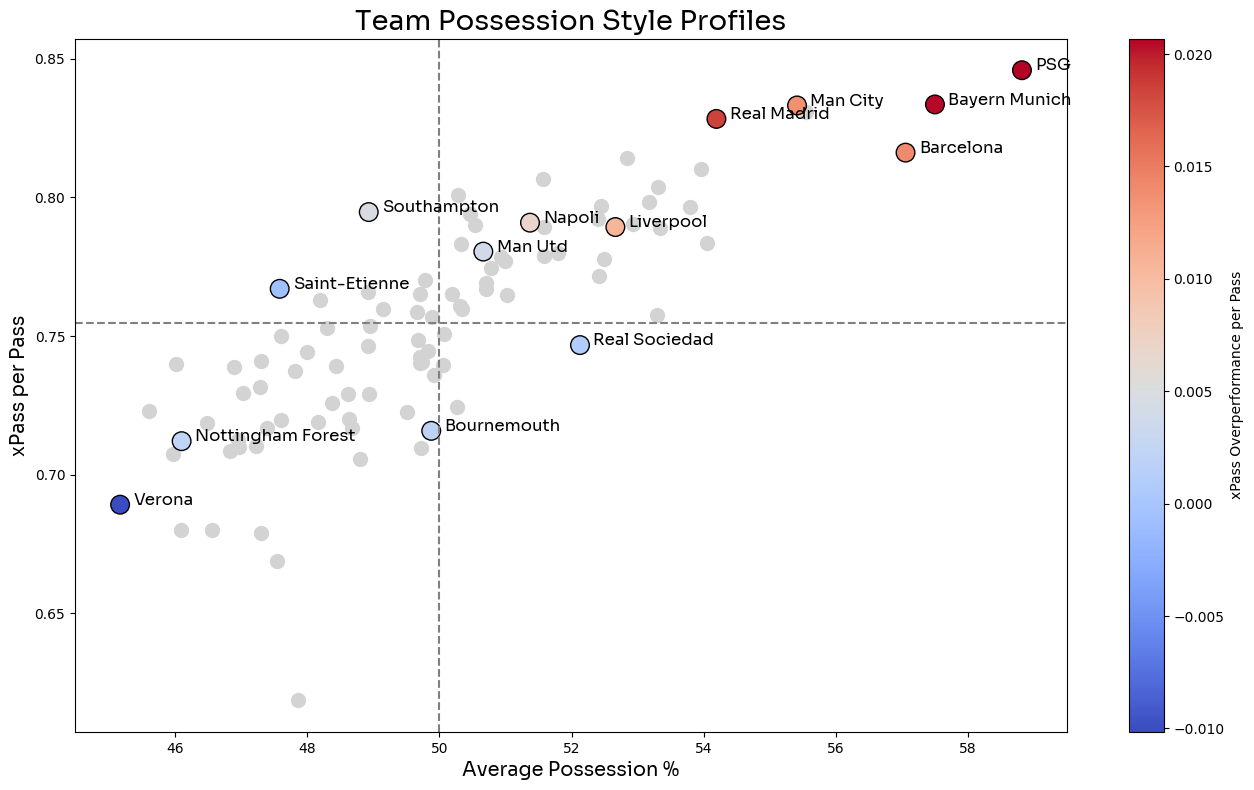

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# Calculate quadrant thresholds
x_mean = team_profile['avg_possession_pct'].mean()
y_mean = team_profile['xPass_per_pass'].mean()

# Function to get the most extreme team in each quadrant
def get_extreme_teams(df):
    q1 = df[(df['avg_possession_pct'] > x_mean) & (df['xPass_per_pass'] > y_mean)]
    q2 = df[(df['avg_possession_pct'] < x_mean) & (df['xPass_per_pass'] > y_mean)]
    q3 = df[(df['avg_possession_pct'] < x_mean) & (df['xPass_per_pass'] < y_mean)]
    q4 = df[(df['avg_possession_pct'] > x_mean) & (df['xPass_per_pass'] < y_mean)]

    return pd.concat([
        q1.loc[[((q1['avg_possession_pct'] - x_mean)**2 + (q1['xPass_per_pass'] - y_mean)**2).idxmax()]],
        q2.loc[[((q2['avg_possession_pct'] - x_mean)**2 + (q2['xPass_per_pass'] - y_mean)**2).idxmax()]],
        q3.loc[[((q3['avg_possession_pct'] - x_mean)**2 + (q3['xPass_per_pass'] - y_mean)**2).idxmax()]],
        q4.loc[[((q4['avg_possession_pct'] - x_mean)**2 + (q4['xPass_per_pass'] - y_mean)**2).idxmax()]],
    ])

# Get extreme teams
#highlight_teams = get_extreme_teams(team_profile)

# List of teams you want to manually include
manual_teams = ['Liverpool', 'Man City', 'Barcelona' , 'Real Madrid' , 'Napoli', 'Bayern Munich', 'Southampton','Bournemouth','Man Utd','Nottingham Forest']

# Get their rows from the main dataframe
manual_rows = team_profile[team_profile['teamName'].isin(manual_teams)]

# Combine with automatically detected extremes
highlight_teams = pd.concat([
    get_extreme_teams(team_profile),
    manual_rows
]).drop_duplicates()


# Plot all teams in grey
plt.figure(figsize=(16, 9))
plt.scatter(
    team_profile['avg_possession_pct'],
    team_profile['xPass_per_pass'],
    c='lightgrey',
    s=100,
    label='Other Teams'
)

# Highlight extreme teams with color by overperformance
scatter = plt.scatter(
    highlight_teams['avg_possession_pct'],
    highlight_teams['xPass_per_pass'],
    c=highlight_teams['overperformance'],
    cmap='coolwarm',
    s=180,
    edgecolor='black',
    label='Highlighted Teams'
)

# Label highlighted teams
for _, row in highlight_teams.iterrows():
    plt.text(row['avg_possession_pct'] + 0.2, row['xPass_per_pass'], row['teamName'],fontproperties=font_prop, fontsize=12, weight='bold')

# Axes, grid, lines
plt.axhline(y=y_mean, color='grey', linestyle='--')
plt.axvline(x=x_mean, color='grey', linestyle='--')
plt.xlabel('Average Possession %',fontproperties=font_prop,fontsize=14)
plt.ylabel('xPass per Pass',fontproperties=font_prop,fontsize=14)
plt.title('Team Possession Style Profiles',fontproperties=font_prop,fontsize=20)
plt.colorbar(scatter, label='xPass Overperformance per Pass')
plt.grid(False)

plt.savefig(f'{plot_path}/xPass/PossVxPass.png',dpi=500,bbox_inches = 'tight',facecolor='white')


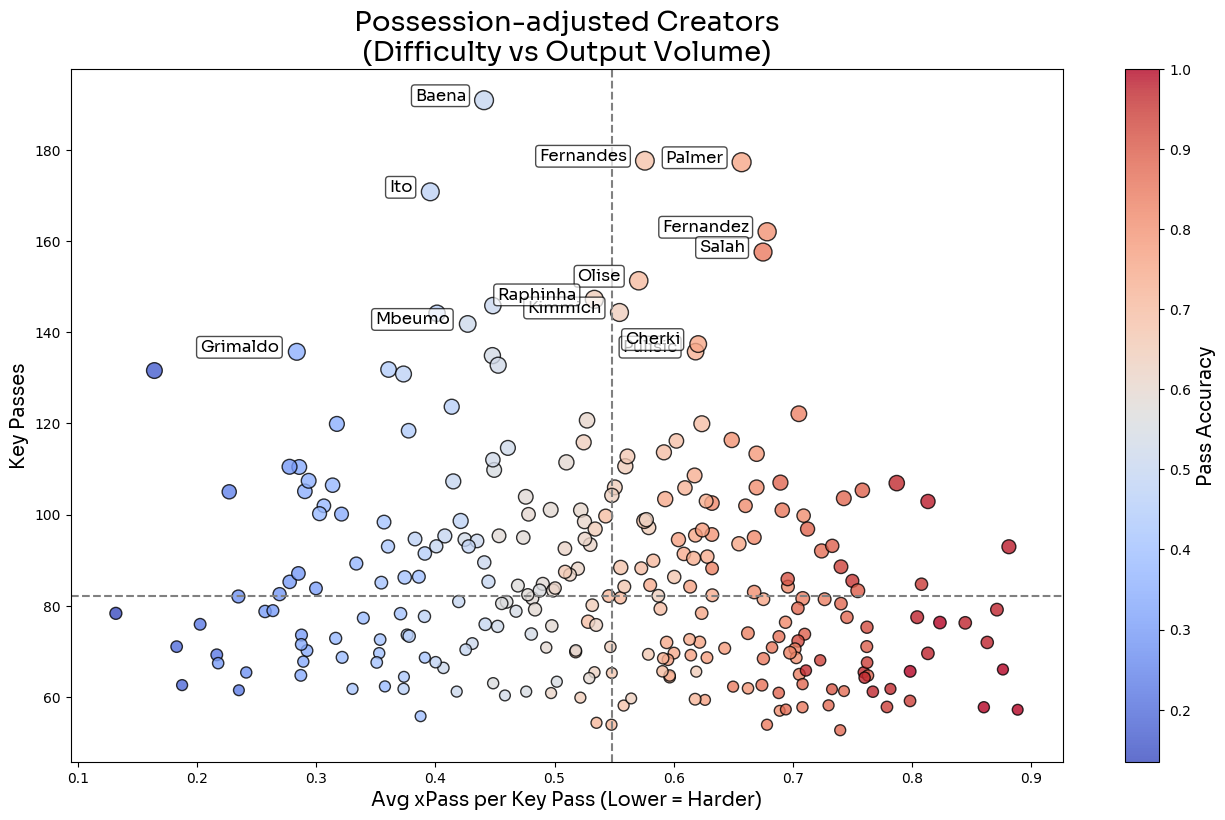

In [27]:
import matplotlib.pyplot as plt
import pandas as pd

# Step 1: Filter key passes and drop NA
key_passes = poss_df[
    (poss_df['passKey'] == True) &
    (~poss_df['xPass'].isna()) &
    (~poss_df['passAccurate'].isna())
].copy()

# Step 2: Merge with team possession %
key_passes = key_passes.merge(
    team_profile[['teamName', 'avg_possession_pct']],
    on='teamName',
    how='left'
)

# Step 3: Group by player
creator_stats = key_passes.groupby('playerName').agg(
    key_passes=('xPass', 'count'),
    avg_xPass=('xPass', 'mean'),
    pass_accuracy=('passAccurate', 'mean'),
    team_possession=('avg_possession_pct', 'first')
).reset_index()

# Step 4: Possession-adjusted metrics
creator_stats['key_passes_per_100_poss'] = creator_stats['key_passes'] / creator_stats['team_possession'] * 100

# Filter: Only players with enough involvement
creator_stats = creator_stats[creator_stats['key_passes'] >= 30].copy()

# Step 5: Plot
plt.figure(figsize=(16, 9))
scatter = plt.scatter(
    creator_stats['avg_xPass'],
    creator_stats['key_passes_per_100_poss'],
    c=creator_stats['pass_accuracy'],
    cmap='coolwarm',
    s=creator_stats['key_passes'] * 2,
    alpha=0.8,
    edgecolor='k'
)

# Median lines
plt.axvline(creator_stats['avg_xPass'].median(), color='gray', linestyle='--')
plt.axhline(creator_stats['key_passes_per_100_poss'].median(), color='gray', linestyle='--')

# Labels for extreme performers
for _, row in creator_stats.iterrows():
    if row['key_passes'] > creator_stats['key_passes'].quantile(0.95):
        # Handle last name safely
        name_parts = row['playerName'].split(' ')
        label = name_parts[-1] if len(name_parts) > 1 else name_parts[0]
        
        plt.text(
            row['avg_xPass'] - 0.015, 
            row['key_passes_per_100_poss'], 
            label,
            fontproperties=font_prop,
            fontsize=12,
            ha='right',
            bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.2', alpha=0.7)
        )

# Axis labels and title
plt.xlabel('Avg xPass per Key Pass (Lower = Harder)',fontproperties=font_prop,fontsize=14)
plt.ylabel('Key Passes',fontproperties=font_prop,fontsize=14)
plt.title('Possession-adjusted Creators\n(Difficulty vs Output Volume)',fontproperties=font_prop,fontsize=20)
cbar = plt.colorbar(scatter)
cbar.set_label('Pass Accuracy',fontproperties=font_prop,fontsize=14)

plt.grid(False)

plt.savefig(f'{plot_path}/xPass/TrueCreators.png',dpi=500,bbox_inches = 'tight',facecolor='white')


In [226]:
xPdf[xPdf['passCrossAccurate'] == 1]['passAccurate'].value_counts()

passAccurate
0.0    14979
Name: count, dtype: int64

In [29]:
import pandas as pd

# Define pass type conditions using both accurate/inaccurate flags
pass_types = {
    'regular': pos_xPdf[
        (pos_xPdf['passCrossAccurate'] != 1) & (pos_xPdf['passCrossInaccurate'] != 1) &
        (pos_xPdf['passLongBallAccurate'] != 1) & (pos_xPdf['passLongBallInaccurate'] != 1) &
        (pos_xPdf['passThroughBallAccurate'] != 1) & (pos_xPdf['passThroughBallInaccurate'] != 1)
    ].assign(pass_success=lambda df: df['passAccurate'].fillna(0)),

    'cross': pos_xPdf[
        (pos_xPdf['passCrossAccurate'] == 1) | (pos_xPdf['passCrossInaccurate'] == 1)
    ].assign(pass_success=lambda df: df['passCrossAccurate'].fillna(0)),

    'long_ball': pos_xPdf[
        (pos_xPdf['passLongBallAccurate'] == 1) | (pos_xPdf['passLongBallInaccurate'] == 1)
    ].assign(pass_success=lambda df: df['passLongBallAccurate'].fillna(0)),

    'through_ball': pos_xPdf[
        (pos_xPdf['passThroughBallAccurate'] == 1) | (pos_xPdf['passThroughBallInaccurate'] == 1)
    ].assign(pass_success=lambda df: df['passThroughBallAccurate'].fillna(0)),
}

# Merge possession % into pos_xPdf via teamId
pos_xPdf = pos_xPdf.merge(
    team_profile[['teamName', 'avg_possession_pct']],
    on='teamName',
    how='left'
)

leaderboard_tables = []

for pass_type, df in pass_types.items():
    # Remove rows without player name
    df = df[df['playerName'].notna()].copy()

    # Group by player and team
    stats = df.groupby(['playerName', 'teamName']).agg(
        passes_attempted=('xPass', 'count'),
        passes_completed=('pass_success', 'sum'),
        xPass_total=('xPass', 'sum'),
    ).reset_index()

    # Add possession %
    stats = stats.merge(
        team_profile[['teamName', 'avg_possession_pct']],
        on='teamName',
        how='left'
    )

    # Filter players with minimum number of passes (e.g., 10)
    stats = stats[stats['passes_attempted'] >= 10].copy()

    # Possession-adjusted overperformance
    stats['paxp_per_100_poss'] = ((stats['passes_completed'] - stats['xPass_total']) / stats['avg_possession_pct']) * 100

    # Add pass type
    stats['pass_type'] = pass_type

    # Get top 5
    top5 = stats.sort_values('paxp_per_100_poss', ascending=False).head(5)
    leaderboard_tables.append(top5)

# Combine into final leaderboard
leaderboard_df = pd.concat(leaderboard_tables, ignore_index=True)

# Optional: Format and sort
leaderboard_df = leaderboard_df[['pass_type', 'playerName', 'passes_attempted', 'passes_completed', 'xPass_total', 'paxp_per_100_poss']]
leaderboard_df = leaderboard_df.sort_values(['pass_type', 'paxp_per_100_poss'], ascending=[True, False])

,playerName,passes_attempted,passes_completed,xPass_total,paxp_per_100


/var/folders/1p/x285c99d20ggyt7j19j59bdm0000gn/T/ipykernel_88493/3040544133.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(colormaps.get(ptype, 'Greys'), len(df) + 2)
/var/folders/1p/x285c99d20ggyt7j19j59bdm0000gn/T/ipykernel_88493/3040544133.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(colormaps.get(ptype, 'Greys'), len(df) + 2)
/var/folders/1p/x285c99d20ggyt7j19j59bdm0000gn/T/ipykernel_88493/3040544133.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.ge

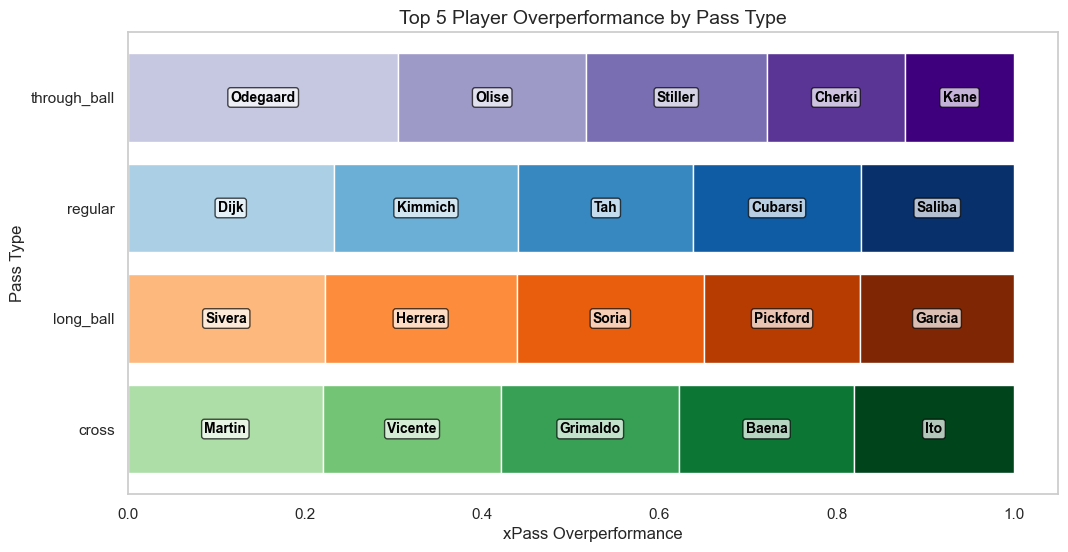

In [43]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Calculate overperformance
leaderboard_df['overperformance'] = leaderboard_df['passes_completed'] - leaderboard_df['xPass_total']

# Get top 5 players per pass type
top_players_by_type = {}
for ptype in leaderboard_df['pass_type'].unique():
    top5 = leaderboard_df[leaderboard_df['pass_type'] == ptype].nlargest(5, 'overperformance')
    top_players_by_type[ptype] = top5

# Colormaps for each pass type
colormaps = {
    'regular': 'Blues',
    'cross': 'Greens',
    'long_ball': 'Oranges',
    'through_ball': 'Purples'
}

# Create stacked bar chart
fig, ax = plt.subplots(figsize=(12, 6))
absolute_values = {}

for idx, (ptype, df) in enumerate(top_players_by_type.items()):
    df = df.copy()
    total_overperf = df['overperformance'].sum()
    absolute_values[ptype] = total_overperf
    df['norm'] = df['overperformance'] / total_overperf

    cmap = cm.get_cmap(colormaps.get(ptype, 'Greys'), len(df) + 2)
    colors = [cmap(i) for i in range(2, len(df) + 2)]

    left = 0
    for i, (player, row) in enumerate(df.set_index('playerName').iterrows()):
        width = row['norm']
        bar = ax.barh(ptype, width, left=left, color=colors[i], edgecolor='white')

        # Add label with last name if wide enough
        if width > 0.05:
            last_name = player.split(' ')[-1]
            ax.text(
                left + width / 2, idx,
                last_name,
                bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.2', alpha=0.7),
                ha='center', va='center',
                fontsize=10, color='black', fontweight='bold'
            )
        left += width

# Labels
ax.set_xlabel('xPass Overperformance', fontsize=12)
ax.set_ylabel('Pass Type', fontsize=12)
ax.set_title('Top 5 Player Overperformance by Pass Type', fontsize=14)

ax.grid(False)

plt.savefig(f'{plot_path}/xPass/xPassByPassType.png',dpi=500,bbox_inches = 'tight',facecolor='white')


In [47]:
player_stats.columns

Index(['playerName', 'passes_attempted', 'passes_completed', 'xPass_total',
       'paxp_per_100'],
      dtype='object')

In [51]:
# Step 1: Count accurate passes per player
accurate_pass_counts = xPdf[xPdf['passAccurate'] == 1].groupby('playerName')['passAccurate'].count()

# Step 2: Filter players with at least 1000 accurate passes
eligible_players = accurate_pass_counts[accurate_pass_counts >= 1000].index

# Step 3: Compute mean xPass for eligible players
mean_xpass = xPdf[xPdf['playerName'].isin(eligible_players)].groupby('playerName')['xPass'].mean().sort_values()

# Step 4: Get the player with the lowest mean xPass
lowest_xpass_player = mean_xpass.index[0]
print(f"Lowest mean xPass player (min 1000 accurate passes): {lowest_xpass_player}")

# Step 5: Filter data for this player
player_df = xPdf[(xPdf['playerName'] == lowest_xpass_player) & xPdf['xPass'].notna()]


Lowest mean xPass player (min 1000 accurate passes): Pedro Porro


/Users/ishdeepchadha/.local/pipx/venvs/notebook/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2911: RuntimeWarning: divide by zero encountered in dot
  c = dot(X, X_T.conj())
/Users/ishdeepchadha/.local/pipx/venvs/notebook/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2911: RuntimeWarning: overflow encountered in dot
  c = dot(X, X_T.conj())
/Users/ishdeepchadha/.local/pipx/venvs/notebook/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2911: RuntimeWarning: invalid value encountered in dot
  c = dot(X, X_T.conj())


Text(0.5, 1.0, 'xPass-Weighted Heatmap: Pedro Porro')

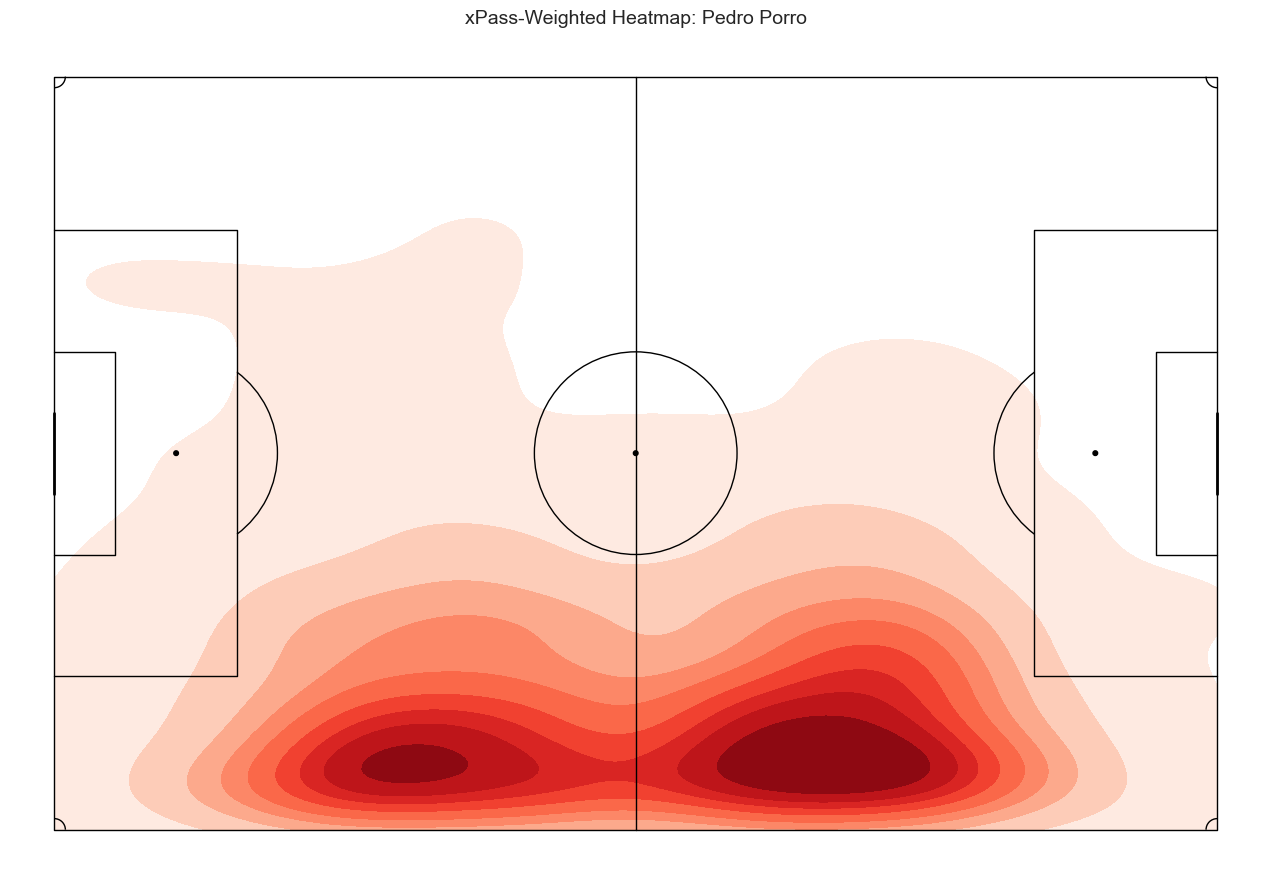

In [57]:
# Optional: Filter to only successful open play passes
# player_df = player_df[(player_df['situation'] == 'OpenPlay') & (player_df['passAccurate'] == 1)]

# Initialize pitch
pitch = Pitch(pitch_type='uefa',half=False, corner_arcs=True, pitch_color='white', line_color='black', linewidth=1)
fig, ax = pitch.draw(figsize=(16, 9))

# Plot KDE weighted by xPass
pitch.kdeplot(
    x=player_df['x'],
    y=player_df['y'],
    ax=ax,
    fill=True,
    cmap='Reds',
    n_levels=10,
    bw_adjust=1,
    weights=player_df['xPass'],
    thresh=0.01,
    zorder=0
)

# Title
ax.set_title(f"xPass-Weighted Heatmap: {lowest_xpass_player}", fontsize=14)

In [131]:
laliga = xPdf[xPdf['league'] == 'laliga']

# Filter valid players
player_df = laliga[~laliga['playerName'].isna() & (laliga['playerName'] != '')].copy()

# Merge in possession %
player_df = player_df.merge(
    team_profile[['teamName', 'avg_possession_pct']],
    on='teamName',
    how='left'
)

# Identify take-ons and carries from the 'type' column
player_df['is_take_on'] = player_df['type'].str.lower().eq('takeon')
player_df['is_carry'] = player_df['type'].str.lower().eq('carry')

# Group by player for raw metrics
player_stats_raw = player_df.groupby(['playerName', 'teamName']).agg(
    passes_attempted=('xPass', 'count'),
    passes_completed=('passAccurate', 'sum'),
    xPass_total=('xPass', 'sum'),
    key_passes=('passKey', 'sum'),
    take_ons=('is_take_on', 'sum'),
    carries=('is_carry', 'sum')
).reset_index()

# Pass Completion %
player_stats_raw['pass_completion_pct'] = (
    player_stats_raw['passes_completed'] / player_stats_raw['passes_attempted'] * 100
)

# Passes Above Expected Pass (raw)
player_stats_raw['paxp'] = player_stats_raw['passes_completed'] - player_stats_raw['xPass_total']

# ===== Possession Adjusted =====
league_avg_poss = player_stats_raw['teamName'].map(
    team_profile.set_index('teamName')['avg_possession_pct']
).mean()

player_stats_raw = player_stats_raw.merge(
    team_profile[['teamName', 'avg_possession_pct']],
    on='teamName',
    how='left'
)

scale_factor = league_avg_poss / player_stats_raw['avg_possession_pct']

player_stats_raw['paxp_adj'] = player_stats_raw['paxp'] * scale_factor
player_stats_raw['key_passes_adj'] = player_stats_raw['key_passes'] * scale_factor
player_stats_raw['take_ons_adj'] = player_stats_raw['take_ons'] * scale_factor
player_stats_raw['pass_completion_pct_adj'] = player_stats_raw['pass_completion_pct'] * scale_factor
player_stats_raw['carries_adj'] = player_stats_raw['carries'] * scale_factor

# ===== Pick specific player for radar =====
player_name = "Omar El Hilali"  # replace with your player
radar_row = player_stats_raw[player_stats_raw['playerName'] == player_name].iloc[0]

metrics = [
    'Passes above expected Pass',
    'Key Passes',
    'TakeOns',
    'Pass Completion %',
    'Carries'
]

raw_values = [
    radar_row['paxp'],
    radar_row['key_passes'],
    radar_row['take_ons'],
    radar_row['pass_completion_pct'],
    radar_row['carries']
]

adj_values = [
    radar_row['paxp_adj'],
    radar_row['key_passes_adj'],
    radar_row['take_ons_adj'],
    radar_row['pass_completion_pct_adj'],
    radar_row['carries_adj']
]


In [132]:
raw_values

[np.float64(6.03778076171875),
 np.float64(8.0),
 np.int64(29),
 np.float64(62.70648030495553),
 np.int64(0)]

In [133]:
adj_values

[np.float64(6.569657641100781),
 np.float64(8.704731622922491),
 np.float64(31.55465213309403),
 np.float64(68.23038525908909),
 np.float64(0.0)]